# Optuna Logistic Regression Feature Test

This notebook keeps the same train/test split, CV settings, and Logistic Regression Optuna search setup as `main_Optuna_automated.ipynb`, while:

1. applying custom stop words to the word TF-IDF vectorizer,
2. searching which engineered features to keep with Optuna,
3. reporting how each engineered feature affects the score.


In [14]:
import pickle

import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd

from optuna.samplers import TPESampler
from scipy.sparse import csr_matrix, hstack
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, f1_score, precision_score, recall_score, roc_auc_score
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.preprocessing import StandardScaler

from toxic_pipeline import (
    ALL_ENGINEERED_FEATURE_COLUMNS,
    WORD_TFIDF_CONFIG as PIPELINE_WORD_TFIDF_CONFIG,
    build_all_engineered_features,
    clean_text,
    protect_non_toxic_negations,
)

print('All imports OK')
print(f'optuna version: {optuna.__version__}')


All imports OK
optuna version: 4.8.0


In [15]:
DATA_PATH = '../data/train.csv'
LABEL_COLUMNS_TO_DROP = ['severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']

SEARCH_RANDOM_STATE = 42
SEARCH_TEST_SIZE = 0.20
SEARCH_CV_SPLITS = 3
OPTUNA_TRIALS_PER_MODEL = 20
SEARCH_CLASS_WEIGHTS = ['balanced', {0: 1, 1: 3}]

WORD_TFIDF_CONFIG = dict(PIPELINE_WORD_TFIDF_CONFIG)
SCALER_CONFIG = {'with_mean': False}
LR_FIXED_MAX_ITER = 500
LR_FINAL_MAX_ITER = 2000

LR_OPTUNA_MODEL_BASE_CONFIG = {
    'max_iter': LR_FIXED_MAX_ITER,
    'random_state': SEARCH_RANDOM_STATE,
    'n_jobs': None,
    'solver': 'liblinear',
}
LR_FINAL_MODEL_CONFIG = {
    'max_iter': LR_FINAL_MAX_ITER,
    'random_state': SEARCH_RANDOM_STATE,
    'n_jobs': None,
    'solver': 'liblinear',
}
LR_OPTUNA_C_RANGE = (3e-2, 3.0)
LR_OPTUNA_TOL_RANGE = (1e-5, 1e-3)

FEATURE_TEST_WORD_VECTORIZER_PATH = 'optuna_feature_test_word_vectorizer.pkl'
FEATURE_TEST_SCALER_PATH = 'optuna_feature_test_scaler.pkl'
FEATURE_TEST_MODEL_PATH = 'optuna_feature_test_best_model.pkl'
FEATURE_TEST_METADATA_PATH = 'optuna_feature_test_metadata.pkl'

print('Vectorizer config ready')


Vectorizer config ready


In [16]:
df = pd.read_csv(DATA_PATH)
df = df.drop(columns=LABEL_COLUMNS_TO_DROP)

df['raw_text'] = df['comment_text'].fillna('').astype(str)
df['protected_text'] = df['raw_text'].apply(protect_non_toxic_negations)
df['clean_text'] = df['protected_text'].apply(clean_text)
df = df[df['clean_text'] != ''].copy()
df = df.drop_duplicates(subset=['clean_text']).reset_index(drop=True)

print(f'Dataset shape after cleaning: {df.shape}')
print(df['toxic'].value_counts())


Dataset shape after cleaning: (158194, 6)
toxic
0    143038
1     15156
Name: count, dtype: int64


In [17]:
print('Feature helpers are imported from toxic_pipeline.py')


Feature helpers are imported from toxic_pipeline.py


In [18]:
engineered_df = pd.concat(
    [build_all_engineered_features(text) for text in df['raw_text']],
    ignore_index=True,
)
df[ALL_ENGINEERED_FEATURE_COLUMNS] = engineered_df

ENG_FEATURE_COLS = ALL_ENGINEERED_FEATURE_COLUMNS.copy()

print(f'Engineered feature count: {len(ENG_FEATURE_COLS)}')
print(df[ENG_FEATURE_COLS].head(3))


Engineered feature count: 16
   Character Count  Word Count  Exclamation Count  Profanity Count  \
0              264          46                  0                0   
1              112          16                  1                0   
2              233          44                  0                0   

   Strong Toxic Signal Flag  Second-person Pronoun Count  \
0                         0                            0   
1                         0                            0   
2                         0                            0   

   Repeated Character Pattern Count  Average Word Length  Uppercase Ratio  \
0                                 0             4.478261         0.083744   
1                                 0             4.625000         0.109589   
2                                 0             4.272727         0.021505   

   Question Mark Count  Repeated Punctuation Count  Identity-group Term Count  \
0                    1                           0         

In [19]:
X_clean = df['clean_text']
X_eng = df[ENG_FEATURE_COLS]
y = df['toxic']

(
    X_clean_train, X_clean_test,
    X_eng_train, X_eng_test,
    y_train, y_test
) = train_test_split(
    X_clean, X_eng, y,
    test_size=SEARCH_TEST_SIZE,
    random_state=SEARCH_RANDOM_STATE,
    stratify=y
)

print(f'Train: {len(y_train):,} | Test: {len(y_test):,}')
print(f'Toxic ratio (train): {y_train.mean():.3f}')


Train: 126,555 | Test: 31,639
Toxic ratio (train): 0.096


In [20]:
word_vec = TfidfVectorizer(**WORD_TFIDF_CONFIG)
X_word_train = word_vec.fit_transform(X_clean_train)
X_word_test = word_vec.transform(X_clean_test)

scaler = StandardScaler(**SCALER_CONFIG)
X_eng_train_scaled = csr_matrix(scaler.fit_transform(X_eng_train.values))
X_eng_test_scaled = csr_matrix(scaler.transform(X_eng_test.values))

X_text_train = X_word_train
X_text_test = X_word_test
X_all_train = hstack([X_text_train, X_eng_train_scaled], format='csr')
X_all_test = hstack([X_text_test, X_eng_test_scaled], format='csr')

ENG_FEATURE_INDEX = {feature: idx for idx, feature in enumerate(ENG_FEATURE_COLS)}
FEATURE_FLAG_NAMES = {
    feature: 'use_' + ''.join(ch.lower() if ch.isalnum() else '_' for ch in feature).strip('_')
    for feature in ENG_FEATURE_COLS
}

print(f'Word TF-IDF shape: {X_word_train.shape}')
print(f'Text-only matrix: {X_text_train.shape}')
print(f'All-feature matrix: {X_all_train.shape}')


Word TF-IDF shape: (126555, 10000)
Text-only matrix: (126555, 10000)
All-feature matrix: (126555, 10016)


In [21]:
search_cv = StratifiedKFold(
    n_splits=SEARCH_CV_SPLITS,
    shuffle=True,
    random_state=SEARCH_RANDOM_STATE
)

def suggest_class_weight(trial, prefix):
    idx = trial.suggest_int(f'{prefix}_class_weight_idx', 0, len(SEARCH_CLASS_WEIGHTS) - 1)
    return SEARCH_CLASS_WEIGHTS[idx]

def build_feature_matrix(text_matrix, eng_matrix, selected_features):
    if not selected_features:
        return text_matrix
    feature_indices = [ENG_FEATURE_INDEX[feature] for feature in selected_features]
    return hstack([text_matrix, eng_matrix[:, feature_indices]], format='csr')

def suggest_selected_features(trial):
    selected = []
    for feature in ENG_FEATURE_COLS:
        use_feature = trial.suggest_categorical(FEATURE_FLAG_NAMES[feature], [True, False])
        if use_feature:
            selected.append(feature)
    return selected

def objective_lr(trial):
    selected_features = suggest_selected_features(trial)
    X_trial = build_feature_matrix(X_text_train, X_eng_train_scaled, selected_features)
    model = LogisticRegression(
        **LR_OPTUNA_MODEL_BASE_CONFIG,
        penalty=trial.suggest_categorical('penalty', ['l1', 'l2']),
        C=trial.suggest_float('C', LR_OPTUNA_C_RANGE[0], LR_OPTUNA_C_RANGE[1], log=True),
        class_weight=suggest_class_weight(trial, 'lr'),
        tol=trial.suggest_float('tol', LR_OPTUNA_TOL_RANGE[0], LR_OPTUNA_TOL_RANGE[1], log=True)
    )
    trial.set_user_attr('selected_features', selected_features)
    return cross_val_score(model, X_trial, y_train, cv=search_cv, scoring='f1', n_jobs=3).mean()

print(f'Running Optuna LR feature study ({OPTUNA_TRIALS_PER_MODEL} trials x {SEARCH_CV_SPLITS}-fold)...')
lr_study = optuna.create_study(direction='maximize', sampler=TPESampler(seed=SEARCH_RANDOM_STATE))
lr_study.optimize(objective_lr, n_trials=OPTUNA_TRIALS_PER_MODEL)

def materialize_best_lr_trial(best_trial):
    params = dict(best_trial.params)
    selected_features = best_trial.user_attrs.get('selected_features', [])
    for flag_name in FEATURE_FLAG_NAMES.values():
        params.pop(flag_name, None)
    if 'lr_class_weight_idx' in params:
        params['class_weight'] = SEARCH_CLASS_WEIGHTS[params.pop('lr_class_weight_idx')]
    return params, selected_features

best_lr_params, best_selected_features = materialize_best_lr_trial(lr_study.best_trial)
X_best_train = build_feature_matrix(X_text_train, X_eng_train_scaled, best_selected_features)
X_best_test = build_feature_matrix(X_text_test, X_eng_test_scaled, best_selected_features)

best_lr = LogisticRegression(
    **LR_FINAL_MODEL_CONFIG,
    **best_lr_params
)
best_lr.fit(X_best_train, y_train)

print('\nOptuna search complete')
print(f'Best CV F1: {lr_study.best_value:.4f}')
print(f'Best LR params: {best_lr_params}')
print(f'Best selected engineered features ({len(best_selected_features)}): {best_selected_features}')


[I 2026-05-15 21:10:41,378] A new study created in memory with name: no-name-25eb536d-57c2-4ad1-ad45-564dfc0c845b


Running Optuna LR feature study (20 trials x 3-fold)...


[I 2026-05-15 21:11:01,441] Trial 0 finished with value: 0.7584049127840803 and parameters: {'use_character_count': False, 'use_word_count': True, 'use_exclamation_count': True, 'use_profanity_count': False, 'use_strong_toxic_signal_flag': False, 'use_second_person_pronoun_count': False, 'use_repeated_character_pattern_count': True, 'use_average_word_length': False, 'use_uppercase_ratio': False, 'use_question_mark_count': True, 'use_repeated_punctuation_count': True, 'use_identity_group_term_count': False, 'use_url_count': False, 'use_negation_count': False, 'use_non_toxic_negation_pattern_count': True, 'use_short_unclear_without_toxic_signal_flag': True, 'penalty': 'l2', 'C': 2.5608569588600485, 'lr_class_weight_idx': 1, 'tol': 4.066563313514796e-05}. Best is trial 0 with value: 0.7584049127840803.
[I 2026-05-15 21:11:02,567] Trial 1 finished with value: 0.7104050410176176 and parameters: {'use_character_count': False, 'use_word_count': True, 'use_exclamation_count': True, 'use_profan


Optuna search complete
Best CV F1: 0.7683
Best LR params: {'penalty': 'l2', 'C': 1.0567675307931639, 'tol': 0.00023605043231416352, 'class_weight': {0: 1, 1: 3}}
Best selected engineered features (7): ['Character Count', 'Profanity Count', 'Second-person Pronoun Count', 'Repeated Character Pattern Count', 'Uppercase Ratio', 'Identity-group Term Count', 'URL Count']


In [22]:
def evaluate_feature_set(name, selected_features, model_params):
    X_train_eval = build_feature_matrix(X_text_train, X_eng_train_scaled, selected_features)
    X_test_eval = build_feature_matrix(X_text_test, X_eng_test_scaled, selected_features)
    model = LogisticRegression(
        **LR_FINAL_MODEL_CONFIG,
        **model_params
    )
    model.fit(X_train_eval, y_train)
    y_pred = model.predict(X_test_eval)
    y_prob = model.predict_proba(X_test_eval)[:, 1]
    return {
        'name': name,
        'feature_count': len(selected_features),
        'features': ', '.join(selected_features) if selected_features else '(none)',
        'f1': f1_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall': recall_score(y_test, y_pred),
        'roc_auc': roc_auc_score(y_test, y_prob),
        'pred': y_pred,
        'prob': y_prob,
        'model': model
    }

text_only_result = evaluate_feature_set('Text only', [], best_lr_params)
all_feature_result = evaluate_feature_set('Text + all engineered', ENG_FEATURE_COLS, best_lr_params)
best_subset_result = evaluate_feature_set('Text + Optuna subset', best_selected_features, best_lr_params)

summary_df = pd.DataFrame([
    {k: v for k, v in text_only_result.items() if k not in {'pred', 'prob', 'model'}},
    {k: v for k, v in all_feature_result.items() if k not in {'pred', 'prob', 'model'}},
    {k: v for k, v in best_subset_result.items() if k not in {'pred', 'prob', 'model'}}
])

print(summary_df[['name', 'feature_count', 'f1', 'precision', 'recall', 'roc_auc']].to_string(index=False))

print('\nBest subset classification report')
print(classification_report(y_test, best_subset_result['pred'], target_names=['Not Toxic', 'Toxic']))


d:\Code\Repos\CPE232\project\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
d:\Code\Repos\CPE232\project\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
d:\Code\Repos\CPE232\project\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid 

                 name  feature_count       f1  precision   recall  roc_auc
            Text only              0 0.757535   0.778087 0.738040 0.962072
Text + all engineered             16 0.761605   0.765412 0.757836 0.965151
 Text + Optuna subset              7 0.759967   0.768556 0.751567 0.965192

Best subset classification report
              precision    recall  f1-score   support

   Not Toxic       0.97      0.98      0.97     28608
       Toxic       0.77      0.75      0.76      3031

    accuracy                           0.95     31639
   macro avg       0.87      0.86      0.87     31639
weighted avg       0.95      0.95      0.95     31639



In [23]:
single_feature_rows = []
for feature in ENG_FEATURE_COLS:
    result = evaluate_feature_set(feature, [feature], best_lr_params)
    single_feature_rows.append({
        'feature': feature,
        'f1': result['f1'],
        'precision': result['precision'],
        'recall': result['recall'],
        'roc_auc': result['roc_auc'],
        'delta_vs_text_only': result['f1'] - text_only_result['f1']
    })

single_feature_df = pd.DataFrame(single_feature_rows).sort_values('delta_vs_text_only', ascending=False).reset_index(drop=True)
print(single_feature_df.to_string(index=False))


d:\Code\Repos\CPE232\project\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
d:\Code\Repos\CPE232\project\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
d:\Code\Repos\CPE232\project\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid 

                                feature       f1  precision   recall  roc_auc  delta_vs_text_only
                    Question Mark Count 0.759134   0.778896 0.740350 0.962465            0.001599
                        Profanity Count 0.759085   0.774459 0.744309 0.962151            0.001550
             Repeated Punctuation Count 0.758924   0.778819 0.740020 0.962375            0.001389
Short/Unclear Without Toxic Signal Flag 0.758796   0.778549 0.740020 0.962051            0.001261
            Second-person Pronoun Count 0.758725   0.775862 0.742329 0.963205            0.001191
                              URL Count 0.758130   0.778977 0.738370 0.962039            0.000595
       Non-toxic Negation Pattern Count 0.758084   0.778512 0.738700 0.962072            0.000549
                        Uppercase Ratio 0.758008   0.770805 0.745629 0.963933            0.000473
                    Average Word Length 0.757617   0.777894 0.738370 0.962095            0.000082
               Stron

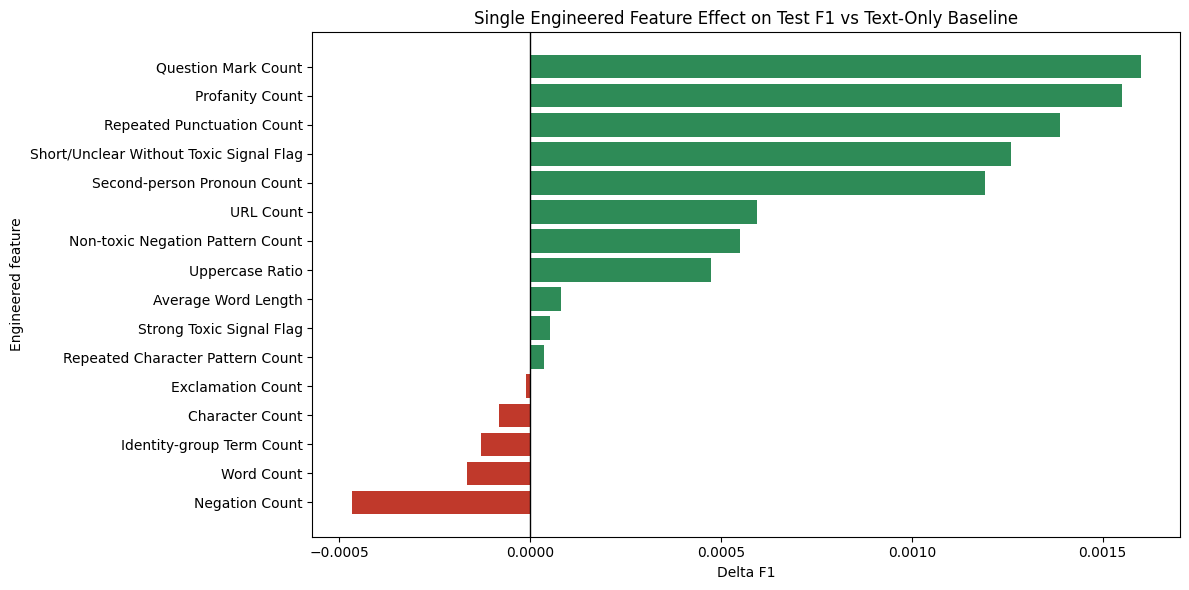

In [24]:
plt.figure(figsize=(12, 6))
plot_df = single_feature_df.sort_values('delta_vs_text_only')
colors = ['#2e8b57' if delta >= 0 else '#c0392b' for delta in plot_df['delta_vs_text_only']]
plt.barh(plot_df['feature'], plot_df['delta_vs_text_only'], color=colors)
plt.axvline(0, color='black', linewidth=1)
plt.title('Single Engineered Feature Effect on Test F1 vs Text-Only Baseline')
plt.xlabel('Delta F1')
plt.ylabel('Engineered feature')
plt.tight_layout()
plt.show()


In [25]:
drop_one_rows = []
for feature in ENG_FEATURE_COLS:
    selected = [f for f in ENG_FEATURE_COLS if f != feature]
    result = evaluate_feature_set(f'All except {feature}', selected, best_lr_params)
    drop_one_rows.append({
        'removed_feature': feature,
        'f1_without_feature': result['f1'],
        'delta_vs_all_features': result['f1'] - all_feature_result['f1']
    })

drop_one_df = pd.DataFrame(drop_one_rows).sort_values('delta_vs_all_features').reset_index(drop=True)
print(drop_one_df.to_string(index=False))


d:\Code\Repos\CPE232\project\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
d:\Code\Repos\CPE232\project\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
d:\Code\Repos\CPE232\project\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid 

                        removed_feature  f1_without_feature  delta_vs_all_features
            Second-person Pronoun Count            0.757581              -0.004024
       Repeated Character Pattern Count            0.760027              -0.001578
                    Question Mark Count            0.760927              -0.000678
                              URL Count            0.760974              -0.000631
                    Average Word Length            0.761352              -0.000252
Short/Unclear Without Toxic Signal Flag            0.761479              -0.000126
                         Negation Count            0.761605               0.000000
                      Exclamation Count            0.761652               0.000047
             Repeated Punctuation Count            0.761731               0.000126
                        Character Count            0.761731               0.000126
       Non-toxic Negation Pattern Count            0.761810               0.000205
    

In [26]:
with open(FEATURE_TEST_WORD_VECTORIZER_PATH, 'wb') as f:
    pickle.dump(word_vec, f)

with open(FEATURE_TEST_SCALER_PATH, 'wb') as f:
    pickle.dump(scaler, f)

with open(FEATURE_TEST_MODEL_PATH, 'wb') as f:
    pickle.dump(best_lr, f)

metadata = {
    'best_cv_f1': lr_study.best_value,
    'best_lr_params': best_lr_params,
    'best_selected_features': best_selected_features,
    'feature_columns': best_selected_features,
    'summary': summary_df.drop(columns=['features']).to_dict(orient='records'),
    'single_feature_effects': single_feature_df.to_dict(orient='records'),
    'drop_one_effects': drop_one_df.to_dict(orient='records'),
    'word_tfidf_config': WORD_TFIDF_CONFIG,
    'final_lr_model_config': LR_FINAL_MODEL_CONFIG,
    'uses_char_vectorizer': False,
}

with open(FEATURE_TEST_METADATA_PATH, 'wb') as f:
    pickle.dump(metadata, f)

print(f'Saved: {FEATURE_TEST_MODEL_PATH}')
print(f'Saved: {FEATURE_TEST_WORD_VECTORIZER_PATH}')
print(f'Saved: {FEATURE_TEST_SCALER_PATH}')
print(f'Saved: {FEATURE_TEST_METADATA_PATH}')


Saved: optuna_feature_test_best_model.pkl
Saved: optuna_feature_test_word_vectorizer.pkl
Saved: optuna_feature_test_scaler.pkl
Saved: optuna_feature_test_metadata.pkl
